# Prediksi Customer Churn — Telco

**Kelompok 12 • Kelas B2**

Muhamad Akhdan Ramadhan (J0404241102), Thevan Erlangga (J0404241073), Fachri Abyasa Tarid (J0404241136).

Notebook ini memakai pipeline terkini. EDA asosiasi dilakukan pada **train saja**. Evaluasi dihitung ulang dari model tersimpan; seluruh training tersedia di `train.py`. Notebook arsip ada di `docs/archive/projekk_awal.ipynb`.

## 1. Masalah, tujuan, dan sumber

Churn berarti pelanggan berhenti berlangganan. Tujuan: membandingkan tiga classifier, mendeteksi kelas churn dengan metrik yang sesuai, dan menyediakan aplikasi single/batch dengan probabilitas terkalibrasi.

[Dataset Telco Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). Target Yes=1, No=0. Ini klasifikasi tabular, bukan forecasting.

[Lima jurnal dan tabel literatur](docs/STUDI_LITERATUR.md).

In [1]:
from pathlib import Path
import json
import joblib
import pandas as pd
from IPython.display import display, Image, Markdown
from eda import run_eda
from training_data import load_training_split
from prediction import input_schema, predict_customers, example_customers
from calibrate import classification_metrics
BASE = Path.cwd()
summary = run_eda()
EDA = BASE / 'docs' / 'eda'
raw = pd.read_csv(BASE / 'Telco-Customer-Churn.csv')
print('Raw shape:', raw.shape)

EDA: 7043 raw -> 7032 clean; 7 grafik -> F:\apaelah\TUGAS\smt5\ML\projek ML\docs\eda
Raw shape: (7043, 21)


## 2. Variabel, tipe data, dan statistik

SeniorCitizen bertipe angka tetapi semantiknya indikator kategori biner; tenure adalah bulan. TotalCharges awalnya string karena nilai kosong. Kolom ID tidak digunakan untuk prediksi pelanggan baru.

In [2]:
display(pd.read_csv(EDA / 'data_dictionary.csv'))
display(pd.read_csv(EDA / 'descriptive_statistics.csv').fillna('—'))

,Variabel,Tipe CSV,Tipe semantik,Jumlah nilai unik,Arti,Peran
0,customerID,str,ID,7043,Identitas unik pelanggan; tidak digunakan model.,dihapus
1,gender,str,kategorikal,2,Jenis kelamin pelanggan (Female/Male).,fitur
2,SeniorCitizen,int64,kategorikal,2,"Indikator pelanggan senior: 1=ya, 0=tidak.",fitur
3,Partner,str,kategorikal,2,Apakah pelanggan memiliki pasangan (Yes/No).,fitur
4,Dependents,str,kategorikal,2,Apakah pelanggan memiliki tanggungan (Yes/No).,fitur
5,tenure,int64,numerik diskrit,73,"Lama berlangganan, dalam bulan.",fitur
6,PhoneService,str,kategorikal,2,Apakah pelanggan memakai layanan telepon (Yes/...,fitur
7,MultipleLines,str,kategorikal,3,Layanan beberapa jalur telepon; No phone servi...,fitur
8,InternetService,str,kategorikal,3,"Jenis internet: DSL, Fiber optic, atau No.",fitur
9,OnlineSecurity,str,kategorikal,3,Layanan keamanan online; No internet service j...,fitur


,Unnamed: 0,count,unique,top,freq,mean,std,min,25%,50%,75%,max
0,customerID,7043.0,7043.0,7590-VHVEG,1.0,—,—,—,—,—,—,—
1,gender,7043.0,2.0,Male,3555.0,—,—,—,—,—,—,—
2,SeniorCitizen,7043.0,—,—,—,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
3,Partner,7043.0,2.0,No,3641.0,—,—,—,—,—,—,—
4,Dependents,7043.0,2.0,No,4933.0,—,—,—,—,—,—,—
5,tenure,7043.0,—,—,—,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
6,PhoneService,7043.0,2.0,Yes,6361.0,—,—,—,—,—,—,—
7,MultipleLines,7043.0,3.0,No,3390.0,—,—,—,—,—,—,—
8,InternetService,7043.0,3.0,Fiber optic,3096.0,—,—,—,—,—,—,—
9,OnlineSecurity,7043.0,3.0,No,3498.0,—,—,—,—,—,—,—


## 3. Missing value, duplikat, dan outlier

Sebelas TotalCharges kosong terdeteksi setelah konversi numerik; seluruhnya tenure 0 dan tidak churn. Penghapusan baris mempertahankan cohort eksperimen awal, namun bukan kewajiban setelah fitur TotalCharges dibuang. Eksklusi pelanggan baru adalah keterbatasan.

Profil identik setelah ID dibuang bisa merupakan pelanggan berbeda. Tidak dihapus otomatis. Pemeriksaan IQR merupakan alat screening, bukan bukti seluruh data bebas anomali.

In [3]:
display(pd.read_csv(EDA / 'missing_values.csv'))
display(pd.DataFrame(summary['duplicates'].items(), columns=['Pemeriksaan','Jumlah']))
display(pd.read_csv(EDA / 'outliers_iqr.csv'))

,Kolom,Missing CSV awal,Missing setelah konversi,Missing cohort bersih
0,customerID,0,0,0
1,gender,0,0,0
2,SeniorCitizen,0,0,0
3,Partner,0,0,0
4,Dependents,0,0,0
5,tenure,0,0,0
6,PhoneService,0,0,0
7,MultipleLines,0,0,0
8,InternetService,0,0,0
9,OnlineSecurity,0,0,0


,Pemeriksaan,Jumlah
0,raw_full_rows,0
1,customerID,0
2,raw_without_id,22
3,clean_without_id_total_including_target,27
4,clean_features_only,48
5,test_features_matching_train,18


,Variabel,Minimum,Maximum,Batas IQR bawah,Batas IQR atas,Jumlah outlier IQR
0,tenure,0.00,72.00,-60.0000,124.0000,0
1,MonthlyCharges,18.25,118.75,-46.0250,171.3750,0
2,TotalCharges,18.80,8684.80,-4688.4813,8884.6688,0


## 4. Visualisasi dan interpretasi

Pemeriksaan kualitas memakai CSV mentah; grafik asosiasi target hanya memakai training set. Setiap grafik dijelaskan di bawahnya.

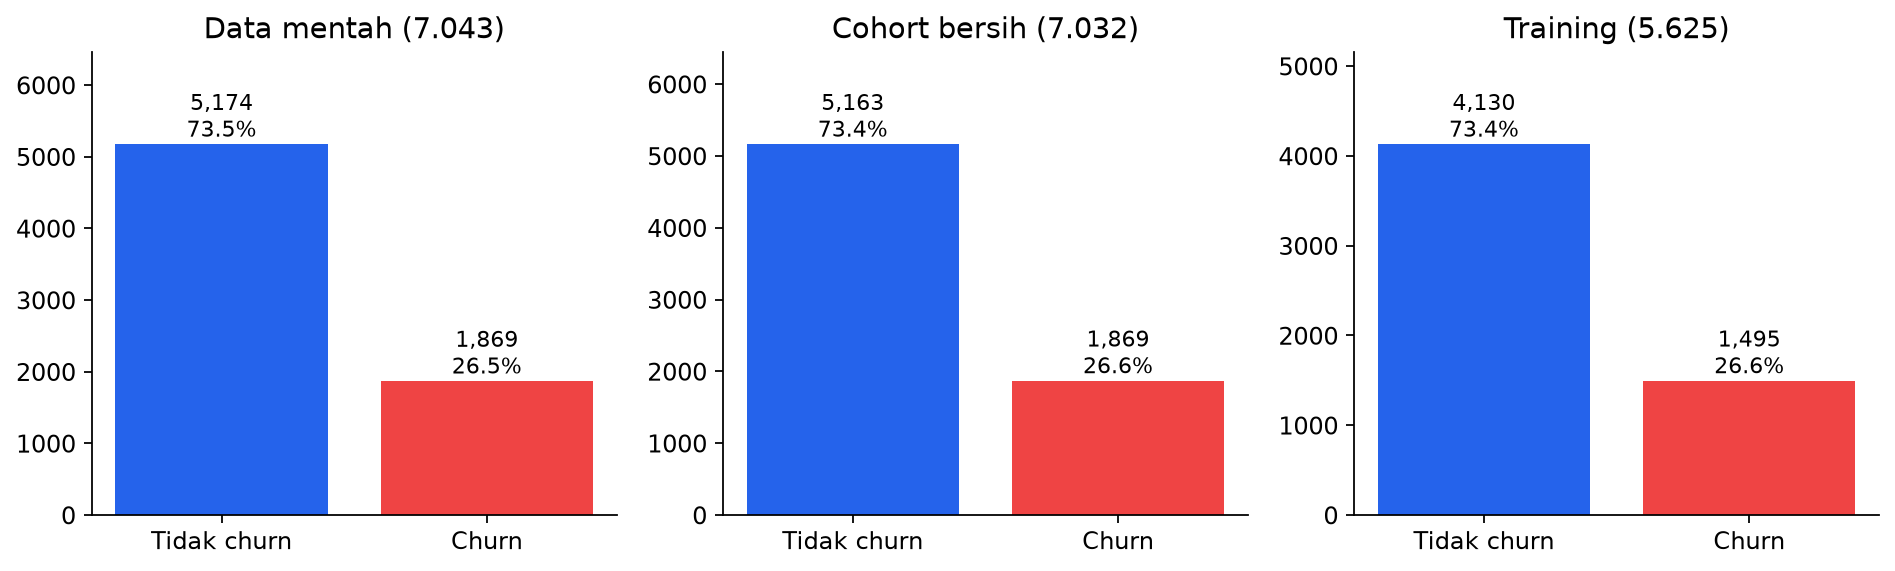

Kelas tidak churn dominan (sekitar 73,4%) dan churn sekitar 26,6% pada cohort bersih. Accuracy saja dapat menutupi kegagalan mendeteksi kelas churn; gunakan precision, recall, dan F1.

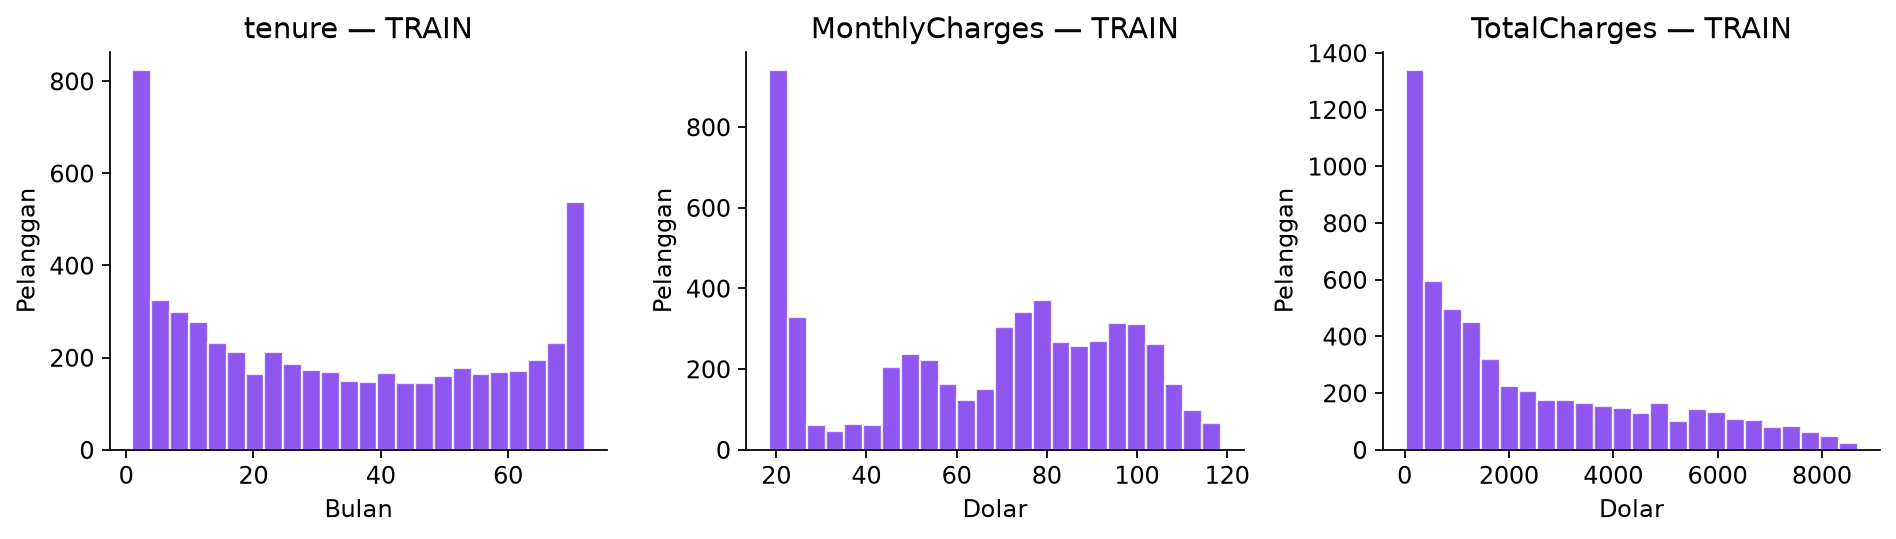

Tenure mencakup pelanggan baru hingga 72 bulan; tagihan memiliki beberapa kelompok sesuai paket layanan. TotalCharges berhubungan dengan durasi berlangganan. Bentuk histogram tidak mengharuskan normalisasi agar normal; StandardScaler digunakan untuk skala numerik Logistic Regression.

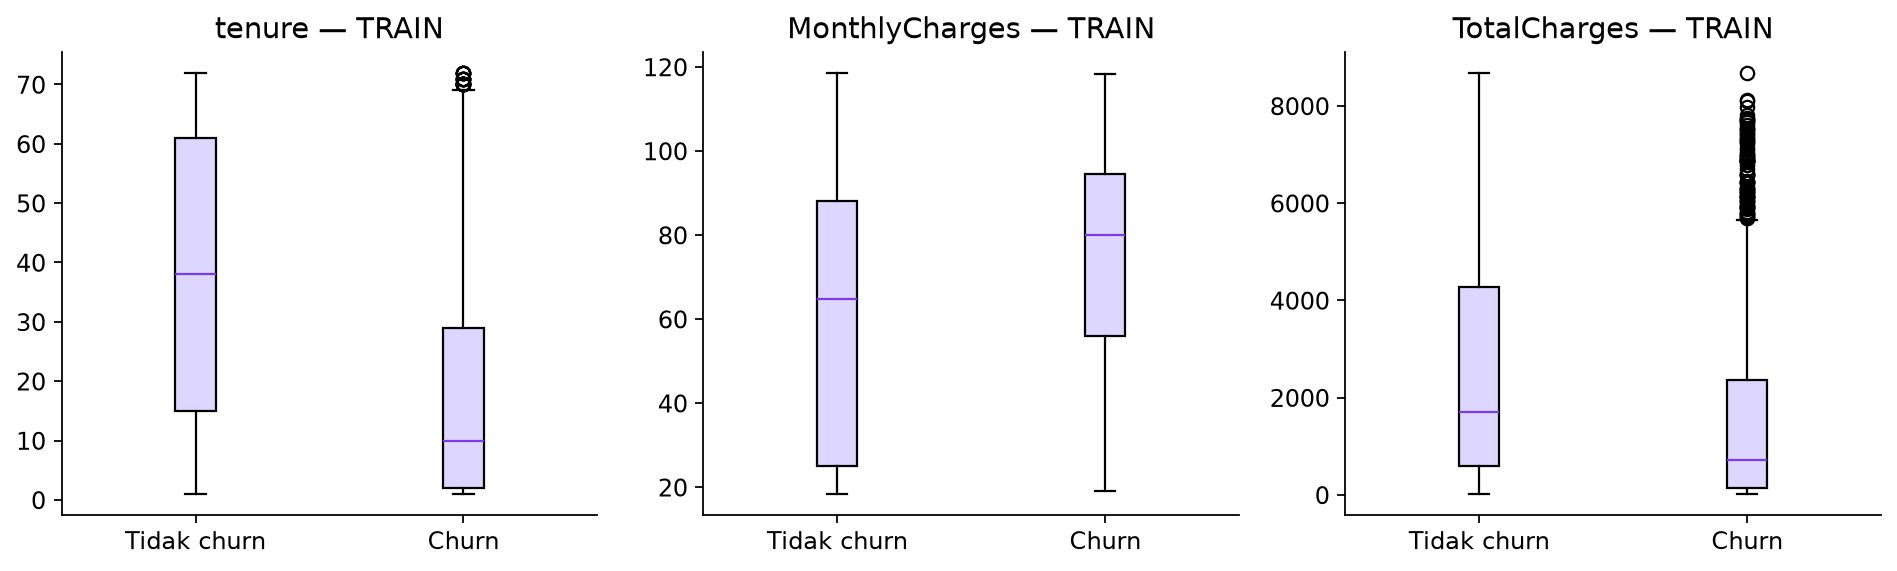

Median tenure pelanggan churn pada train adalah 10 bulan, dibanding 38 bulan pada tidak churn. Median tagihan churn $79.90 vs $64.68. Ini hubungan deskriptif, bukan bukti bahwa menaikkan tagihan atau mengganti kontrak menyebabkan churn. Titik outlier boxplot dihitung per kelas; berbeda dari pemeriksaan IQR seluruh cohort pada tabel kualitas data.

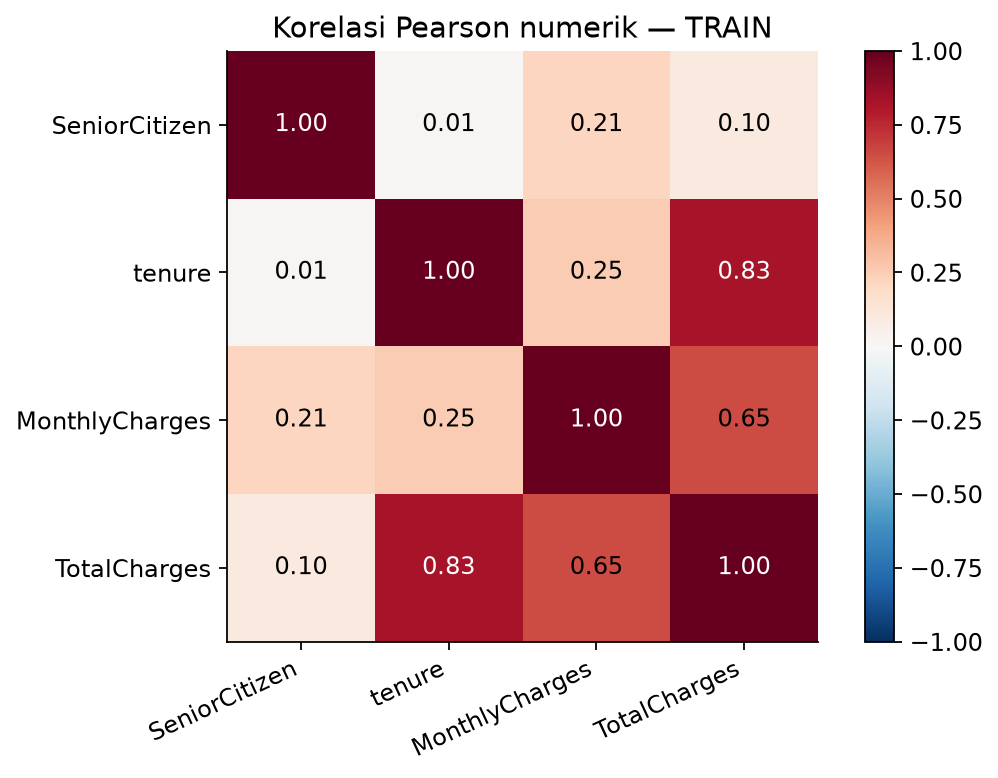

Korelasi TotalCharges–tenure pada train adalah 0.827. Korelasi tinggi tidak membuktikan keduanya identik. TotalCharges dihapus untuk menyederhanakan input; manfaat penghapusan belum diuji dengan ablation.

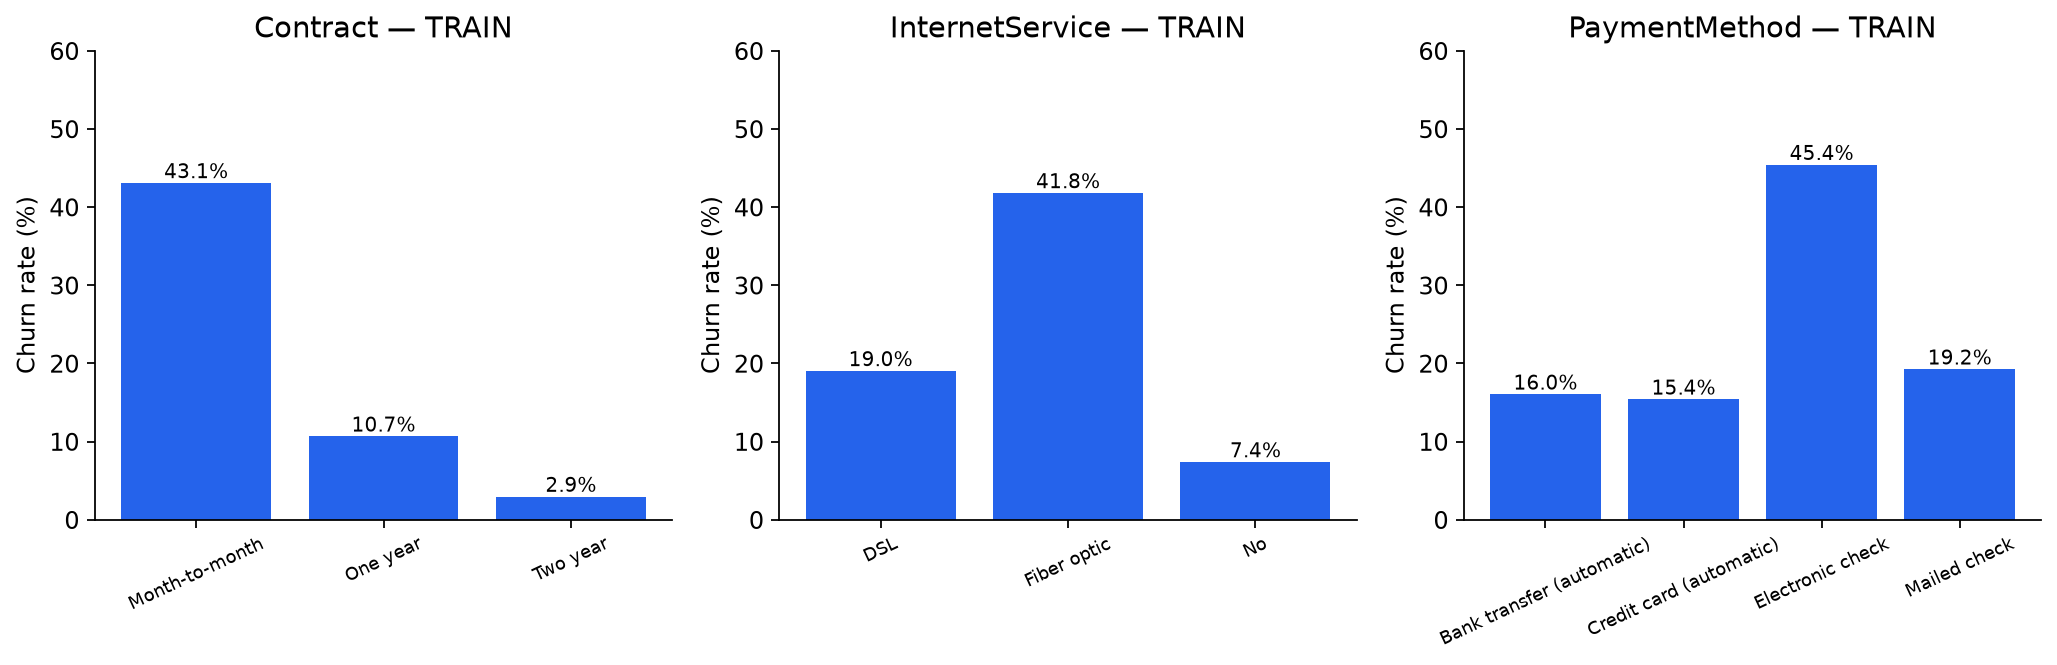

Pada train, churn rate kontrak bulanan 43.1%, sedangkan kontrak dua tahun 2.9%. Pelanggan fiber/electronic check juga memiliki profil churn berbeda. Asosiasi ini mendukung pemilihan fitur, bukan jaminan efektivitas saran retensi.

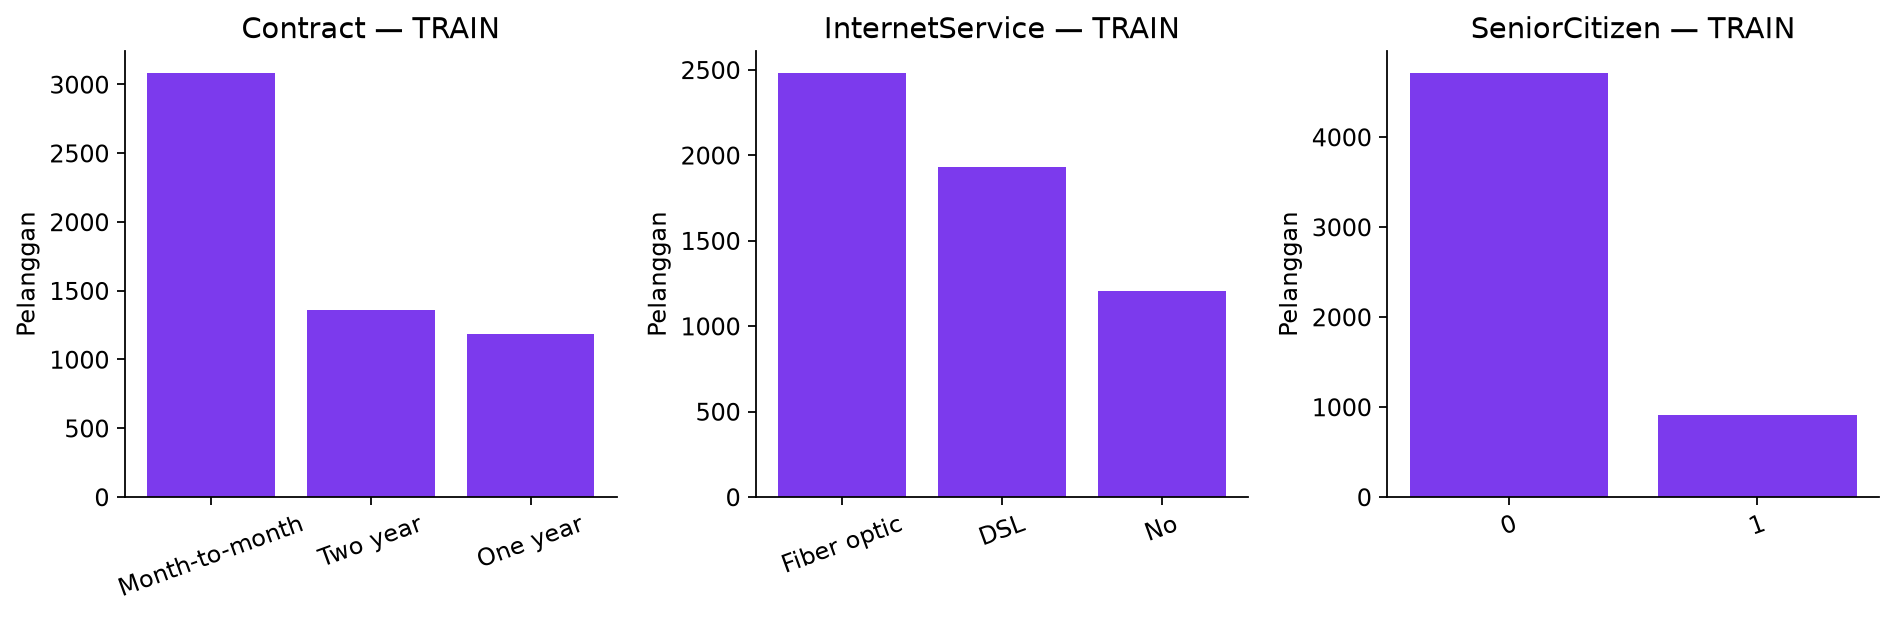

Distribusi kategori menunjukkan sebagian besar pelanggan bukan senior dan kategori kontrak/paket tidak sama besar. Bandingkan churn rate beserta jumlah pelanggan per kategori, sehingga kelompok kecil tidak dianggap mewakili seluruh populasi.

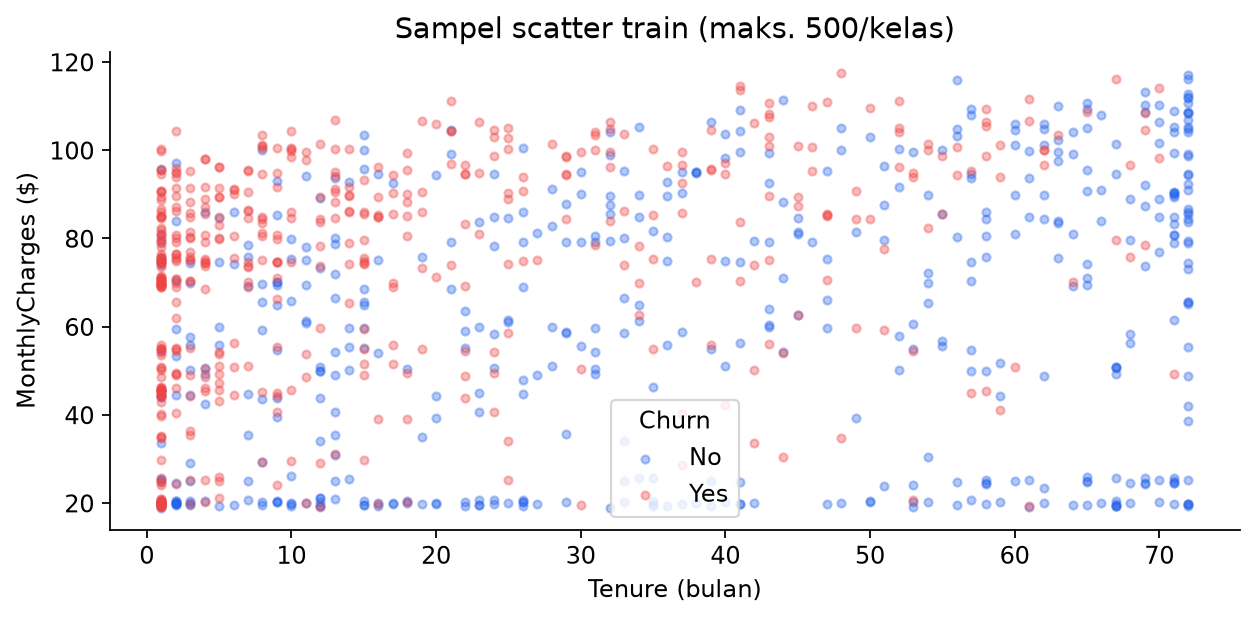

Kedua kelas saling tumpang tindih pada tenure dan tagihan; tidak ada satu batas sederhana yang memisahkan semua pelanggan churn. Grafik memakai sampel per kelas untuk keterbacaan, bukan untuk menghitung proporsi populasi.

In [4]:
for figure in summary['figures']:
    display(Image(filename=str(EDA / figure['file'])))
    display(Markdown(figure['interpretation']))

## 5. Preprocessing dan split

Cohort 7.032 → 5.625 train / 1.407 test secara stratified, random_state=42. customerID dihapus; TotalCharges tidak dipakai agar input lebih sederhana. Tidak mengklaim TotalCharges selalu MonthlyCharges×tenure atau bahwa penghapusan fitur pasti meningkatkan performa.

StandardScaler pada SeniorCitizen, tenure, MonthlyCharges; OneHotEncoder pada 15 kategori. Pipeline fit hanya pada train/fold. Scaling berguna untuk LR; pohon tidak membutuhkannya namun tetap memakai pipeline konsisten. class_weight dituning; tidak menggunakan SMOTE.

In [5]:
X_train, X_test, y_train, y_test = load_training_split()
pipe = joblib.load(BASE / 'model_churn.pkl')
cal = joblib.load(BASE / 'calibrator.pkl')
info = json.loads((BASE / 'model_info.json').read_text())
deployment = json.loads((BASE / 'deployment_info.json').read_text())
print('Train/test:', X_train.shape, X_test.shape)
print('Jumlah fitur setelah transformasi:', len(pipe.named_steps['pre'].get_feature_names_out()))
display(pipe)

Train/test: (5625, 18) (1407, 18)
Jumlah fitur setelah transformasi: 44


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['gender','SeniorCitizen','Partner',...,'PaperlessBilling','PaymentMethod', 'MonthlyCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

## 6. Training tiga algoritma dan alasan

- Logistic Regression: baseline linear pada log-odds, ringan dan dapat diinterpretasikan.
- Decision Tree: aturan non-linear/interaksi; kedalaman dituning untuk membatasi kompleksitas.
- Random Forest: ensemble bagging pohon; pembanding model lebih kompleks dan reduksi varians.

Stratified 5-Fold GridSearchCV dengan scoring F1 kelas churn. Hyperparameter dipilih pada train; pemenang berdasarkan CV-F1. Jalankan sel opsional berikut hanya jika ingin membangun ulang seluruh artefak.

In [6]:
RUN_TRAINING = False
if RUN_TRAINING:
    from train import train
    train()
comparison = pd.read_csv(BASE / 'hasil_perbandingan.csv')
display(comparison)
display(pd.read_csv(BASE / 'cv_detail.csv'))

,Model,BestParams,CV_F1,CV_F1_STD,CV_TRAIN_F1,Train_F1,Accuracy,Precision,Recall,F1,ROC_AUC,Brier,TN,FP,FN,TP
0,LogisticRegression,"{'clf__C': 10.0, 'clf__class_weight': 'balanced'}",0.6304,0.0087,0.6354,0.6338,0.7264,0.4908,0.7861,0.6043,0.8321,0.1741,728,305,80,294
1,RandomForest,"{'clf__class_weight': 'balanced_subsample', 'c...",0.6260,0.0126,0.8342,0.8217,0.7697,0.5548,0.6765,0.6096,0.8235,0.1567,830,203,121,253
2,DecisionTree,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6147,0.0083,0.6366,0.6433,0.7363,0.5025,0.7968,0.6163,0.8305,0.1721,738,295,76,298


,Model,Fold,F1
0,LogisticRegression,1,0.6395
1,LogisticRegression,2,0.6263
2,LogisticRegression,3,0.6154
3,LogisticRegression,4,0.6347
4,LogisticRegression,5,0.6364
5,DecisionTree,1,0.6099
6,DecisionTree,2,0.6124
7,DecisionTree,3,0.6310
8,DecisionTree,4,0.6127
9,DecisionTree,5,0.6077


## 7. Analisis perbandingan dan overfitting

LR dipilih dengan CV-F1 0,6304; RF 0,6260; DT 0,6147. Selisih LR–RF kecil dan tidak membuktikan keunggulan mutlak. Pada test, DT memiliki recall/F1 tertinggi model inti dan RF accuracy tertinggi. RF memiliki gap train–validation–test terbesar, indikasi overfitting. Tidak menyimpulkan underfitting hanya dari accuracy yang sedang.

Kemungkinan perbedaan: kompleksitas/interaksi, class_weight, regularisasi, dan split. Baseline selalu tidak churn tetap mendapat accuracy sekitar 73,42% namun recall churn 0.

In [7]:
display(comparison[['Model','Train_F1','CV_TRAIN_F1','CV_F1','CV_F1_STD','F1']])
print('Baseline majority accuracy:', round(float((y_test == 0).mean()), 4))
base_prob = pipe.predict_proba(X_test)[:, 1]
print('Verifikasi model inti:', classification_metrics(y_test, base_prob, 0.5))

,Model,Train_F1,CV_TRAIN_F1,CV_F1,CV_F1_STD,F1
0,LogisticRegression,0.6338,0.6354,0.6304,0.0087,0.6043
1,RandomForest,0.8217,0.8342,0.6260,0.0126,0.6096
2,DecisionTree,0.6433,0.6366,0.6147,0.0083,0.6163


Baseline majority accuracy: 0.7342
Verifikasi model inti: {'Accuracy': 0.7264, 'Precision': 0.4908, 'Recall': 0.7861, 'F1': 0.6043, 'ROC_AUC': 0.8321, 'Brier': 0.1741, 'TN': 728, 'FP': 305, 'FN': 80, 'TP': 294}


## 8. Kalibrasi, threshold, dan evaluasi model aplikasi

Sigmoid calibration train-only. Threshold dipilih dari grid 0,10–0,60 langkah 0,01 dengan F1 maksimum prediksi OOF training, menggunakan kalibrasi di dalam outer training fold. Hyperparameter inti sudah dipilih pada train sehingga skor OOF ini adalah skor tuning, bukan estimasi generalisasi independen. Test tidak digunakan untuk pemilihan threshold.

Probabilitas dan keputusan aplikasi berasal dari model yang sama: CHURN jika p≥0,32. ROC-AUC/Brier tidak berubah bila hanya threshold diubah.

In [8]:
prob, pred = predict_customers(X_test, cal, input_schema(pipe), deployment['threshold'])
actual = classification_metrics(y_test, prob, deployment['threshold'])
assert actual == deployment['metrics']
display(pd.DataFrame([{'Konfigurasi':'Aplikasi threshold 0.32', **actual},
                      {'Konfigurasi':'Kalibrasi threshold 0.50', **deployment['metrics_at_0_5']}]))
print('Threshold:', deployment['threshold'], 'Skor OOF tuning:', deployment['oof_tuning_f1'])

,Konfigurasi,Accuracy,Precision,Recall,F1,ROC_AUC,Brier,TN,FP,FN,TP
0,Aplikasi threshold 0.32,0.7569,0.5309,0.7353,0.6166,0.8324,0.1414,790,243,99,275
1,Kalibrasi threshold 0.50,0.8024,0.6472,0.5642,0.6029,0.8324,0.1414,918,115,163,211


Threshold: 0.32 Skor OOF tuning: 0.6338


## 9. Kesalahan prediksi dan interpretasi

Aplikasi: TP 275, TN 790, FP 243, FN 99. Precision 53,09% dan recall 73,53% menjelaskan trade-off retensi; CHURN bukan kepastian. Koefisien model inti menunjukkan hubungan dengan log-odds dengan fitur lain tetap; bukan pengaruh kausal. Bobot numerik terstandardisasi tidak langsung sebanding dengan dummy kategori.

In [9]:
errors = X_test.copy()
errors['Aktual'] = y_test
errors['Prediksi'] = pred
errors['Prob_Churn'] = prob
display(errors[errors.Aktual != errors.Prediksi].head(10))
coefficients = pd.DataFrame({'Fitur': pipe.named_steps['pre'].get_feature_names_out(),
                             'Koefisien': pipe.named_steps['clf'].coef_[0]})
display(coefficients.reindex(coefficients.Koefisien.abs().sort_values(ascending=False).index).head(15))

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Aktual,Prediksi,Prob_Churn
618,Female,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),78.55,0,1,0.593322
3715,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,1,0,0.175697
4276,Male,1,Yes,No,4,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.20,0,1,0.687526
6119,Female,0,Yes,No,14,Yes,No,Fiber optic,No,No,...,No,No,Yes,Month-to-month,Yes,Electronic check,78.10,0,1,0.658819
4645,Female,0,Yes,Yes,30,No,No phone service,DSL,No,No,...,Yes,Yes,Yes,Month-to-month,No,Credit card (automatic),51.20,1,0,0.230806
5375,Female,0,No,No,4,Yes,Yes,DSL,No,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,64.40,0,1,0.440494
558,Male,0,No,No,1,Yes,No,DSL,No,No,...,Yes,No,No,Month-to-month,Yes,Electronic check,49.30,0,1,0.388838
2295,Female,0,Yes,Yes,48,Yes,Yes,Fiber optic,Yes,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.25,1,0,0.164371
975,Male,1,Yes,No,62,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Electronic check,103.75,1,0,0.291994
2963,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,...,No,No,Yes,Month-to-month,No,Electronic check,90.40,0,1,0.648788


,Fitur,Koefisien
2,num__MonthlyCharges,-1.666685
15,cat__InternetService_Fiber optic,1.258932
14,cat__InternetService_DSL,-1.026625
37,cat__Contract_Two year,-0.801933
1,num__tenure,-0.756216
35,cat__Contract_Month-to-month,0.664660
31,cat__StreamingTV_Yes,0.546440
34,cat__StreamingMovies_Yes,0.539154
16,cat__InternetService_No,-0.503461
18,cat__OnlineSecurity_No internet service,-0.503461


## 10. Implementasi, sanity test, dan keterbatasan

Streamlit → validasi 18 input → preprocessing dalam pipeline terkalibrasi → probabilitas → threshold → label/risiko. CSV invalid ditolak dengan pesan; hasil dapat diunduh.

Keterbatasan: dataset historis tunggal, profil identik lintas split, eksklusi tenure 0, F1 moderat, FP/FN tetap ada, saran retensi berbasis aturan belum diuji kausal. Pengembangan: validasi eksternal/temporal, group-aware split, ablation fitur, cost-based threshold, tuning RF, SHAP dan pengujian tindakan retensi.

In [10]:
example = example_customers()
p, labels = predict_customers(example, cal, input_schema(pipe), deployment['threshold'])
example['Prob_Churn'] = p
example['Prediksi'] = labels
display(example)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Prob_Churn,Prediksi
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.0,0.747895,1
1,Female,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),65.0,0.009945,0


## 11. Berkas pengumpulan

- [PPT](docs/ML2026_B2_Kelompok12_PrediksiCustomerChurn.pptx)
- [Naskah video demo](docs/NASKAH_VIDEO_DEMO.md)
- [Studi literatur](docs/STUDI_LITERATUR.md)
- [Laporan EDA](docs/eda/EDA.md)
- [Repository](https://github.com/makhdanramadhan-ui/Machine-Learning-Project)
- [Aplikasi](https://machine-learning-project-u8yovshrqrc5tm5s2y2qto.streamlit.app/)

Pembagian tugas aktual diisi kelompok. Rekaman video asli dilakukan anggota; naskah bukan pengganti video.